# Chapter 1: Polygons

**Source Span.** *Discrete and Computational Geometry, 2nd Edition*, Chapter 1, printed pages 1-37, PDF pages 16-52.

**Chapter goal.** Build a computational view of polygons that connects the Jordan curve theorem intuition, triangulation and ear structure, Catalan counting, art-gallery guards, scissors congruence in the plane, and the 3D Dehn-angle obstruction.

The chapter begins with a finite replacement for vague visual intuition: a polygonal boundary lets us classify points by ray-crossing parity. From there, diagonals split polygons into triangles, ears make induction concrete, and the fixed counts `n - 2` and `n - 3` become graph invariants. Convex polygons expose Catalan growth; triangulated polygons expose Fisk's 3-color guard proof. The final sections compare 2D and 3D scissors congruence: equal area is enough in the plane, but equal volume is not enough in space because dihedral angles leave an obstruction.


## Computational Translation Guide

| Source idea | Computational representation | Inspection target |
| --- | --- | --- |
| Polygonal Jordan curve | horizontal ray-crossing parity, with boundary cases separated | parity is stable away from the boundary and agrees with a robust planar predicate |
| Diagonal and ear | segment-in-polygon tests plus an ear-clipping triangulation | every accepted diagonal lies inside the polygon and each removed ear gives one triangle |
| Triangulation counts | planar graph ledger `V - E + F = 2` | triangles are `n - 2`, diagonals are `n - 3`, independent of the triangulation chosen |
| Convex polygon triangulations | Catalan recurrence and closed formula | recurrence values match the binomial formula for `C_m` |
| Art gallery theorem | triangulation graph, reverse ear 3-coloring, least color class | every triangle has a guard vertex and the least color class has at most `floor(n/3)` vertices |
| Orthogonal and fortress variants | small formula ledger and schematic diagrams | guard bounds change when visibility region or polygon class changes |
| 2D scissors congruence | area ledger through triangle-to-rectangle pieces | dissection bookkeeping preserves total area |
| 3D scissors obstruction | dihedral-angle ledger | equal volume can coexist with incompatible angle data |


## Visual Storyboard

1. **Ray-crossing parity board.** Sample points around a nonconvex polygon, draw rays, and compare a visible crossing count with Shapely's predicate.
2. **Diagonal and ear triangulation visual.** Run an ear-clipping triangulation on the same polygon; mark the diagonals and verify `n - 2`, `n - 3`, and Euler's formula.
3. **Triangulation count table.** Save the count identities for small `n` as a reusable invariant ledger.
4. **Catalan dynamic program plot.** Compute convex-polygon triangulation counts by recurrence and compare them to the closed form.
5. **Fisk guard coloring.** 3-color the triangulation graph by reversing the ear-removal sequence and guard the least color class.
6. **Gallery variants diagram.** Compare the classical, orthogonal, and exterior fortress guard bounds without trying to reprove the variant theorems.
7. **2D scissors area ledger.** Turn triangle areas into unit-width rectangles and stack them, exposing the Wallace-Bolyai-Gerwien proof strategy.
8. **3D Dehn-angle ledger.** Compare two equal-volume tetrahedra by dihedral angles and record why rational multiples of `pi` cannot absorb `arctan(sqrt(2))`.


In [1]:
from pathlib import Path
import csv
import json
import math
import os
from fractions import Fraction

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon, Rectangle, FancyArrowPatch
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from shapely.geometry import LineString, Point, Polygon as ShapelyPolygon
import sympy as sp
from IPython.display import HTML, Image, Markdown, display

UNIT_KEY = "chapter-01-polygons"
UNIT_TITLE = "Polygons"
COURSE_FOLDER = "Discrete-and-Computational-Geometry"


def find_book_root():
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "AGENTS.md").exists() and candidate.name == COURSE_FOLDER:
            return candidate
        nested = candidate / COURSE_FOLDER
        if (nested / "AGENTS.md").exists():
            return nested
    raise RuntimeError("Could not find Discrete-and-Computational-Geometry/AGENTS.md")


BOOK_ROOT = find_book_root()
NOTEBOOK_DIR = BOOK_ROOT / "chapter-01-polygons"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / UNIT_KEY
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

ARTIFACTS = []


def register(path):
    path = Path(path)
    if path not in ARTIFACTS:
        ARTIFACTS.append(path)
    return path


def rel_book(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


def rel_notebook(path):
    return Path(os.path.relpath(Path(path).resolve(), NOTEBOOK_DIR)).as_posix()


def save_json(path, data):
    path = register(path)
    path.write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path


def save_csv(path, rows, fieldnames=None):
    path = register(path)
    if fieldnames is None:
        keys = []
        for row in rows:
            for key in row:
                if key not in keys:
                    keys.append(key)
        fieldnames = keys
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)
    return path


def save_matplotlib(fig, path, *, dpi=180):
    path = register(path)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path


def save_figure(fig, path, dpi=180):
    path = save_matplotlib(fig, path, dpi=dpi)
    plt.close(fig)
    return path


def display_artifact(path, height=430):
    path = Path(path)
    suffix = path.suffix.lower()
    display(Markdown(f"Artifact: `{rel_book(path)}`"))
    if suffix in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(path)))
    elif suffix == ".html":
        display(HTML(
            f'<iframe src="{rel_notebook(path)}" width="100%" height="{height}" '
            'style="border:1px solid #c9c9c9; border-radius:4px;"></iframe>'
        ))


def assert_artifacts(paths, min_bytes=80):
    missing = []
    too_small = []
    for path in paths:
        path = Path(path)
        if not path.exists():
            missing.append(rel_book(path))
        elif path.stat().st_size < min_bytes:
            too_small.append((rel_book(path), path.stat().st_size))
    assert not missing, f"Missing artifacts: {missing}"
    assert not too_small, f"Artifacts too small: {too_small}"


def signed_area(vertices):
    pts = np.asarray(vertices, dtype=float)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def triangle_area(a, b, c):
    return abs(0.5 * ((b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])))


def orient(a, b, c):
    return float((b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0]))


palette = {
    "inside": "#2a9d8f",
    "outside": "#6c757d",
    "boundary": "#d62828",
    "diagonal": "#7b2cbf",
    "guard": "#e76f51",
    "fill": "#e9f5f3",
}

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT}")


Book root: D:\Geometry\Discrete-and-Computational-Geometry
Artifact root: D:\Geometry\Discrete-and-Computational-Geometry\artifacts\chapter-01-polygons


## Source Coverage And Library Routing

The source span was read through `pdftotext` from PDF pages 16-52. The notebook does not reproduce textbook prose or figures; it uses the source as a coverage map for the concepts below.


In [2]:
source_coverage = {
    "Jordan curve theorem intuition": True,
    "polygonal Jordan curve": True,
    "diagonals and triangulation": True,
    "ear and diagonal existence": True,
    "triangulation count n-2 and diagonal count n-3": True,
    "convex polygon Catalan recurrence": True,
    "art gallery theorem and 3-coloring": True,
    "orthogonal gallery variant": True,
    "fortress exterior variant": True,
    "2D scissors congruence": True,
    "3D Dehn dihedral obstruction": True,
}
source_coverage_path = save_json(CHECK_DIR / "source-coverage.json", source_coverage)

routing_rows = [
    {
        "concept": "point-in-polygon parity and diagonal validity",
        "library": "Shapely",
        "why": "robust planar predicates give an independent check on visible crossing and segment tests",
        "artifact": "checks/ray-crossing-parity-checks.json",
    },
    {
        "concept": "triangulation graph and Fisk coloring",
        "library": "NetworkX",
        "why": "boundary plus diagonal edges form the graph whose proper coloring drives the guard proof",
        "artifact": "checks/art-gallery-guard-checks.json",
    },
    {
        "concept": "Catalan recurrence and Dehn angle expressions",
        "library": "SymPy",
        "why": "exact binomial values and symbolic angle expressions keep the arithmetic inspectable",
        "artifact": "checks/catalan-recurrence-checks.json",
    },
    {
        "concept": "interactive Catalan growth",
        "library": "Plotly",
        "why": "the dynamic-programming growth is easier to inspect with hoverable values and a log scale",
        "artifact": "html/catalan-triangulation-growth.html",
    },
    {
        "concept": "durable 2D proof diagrams and ledgers",
        "library": "Matplotlib",
        "why": "static PNG diagrams are reliable for parity rays, ears, guards, scissors ledgers, and angle ledgers",
        "artifact": "figures/*.png",
    },
]
routing_path = save_csv(TABLE_DIR / "library-routing.csv", routing_rows)
display(pd.DataFrame(routing_rows))
display_artifact(source_coverage_path)
display_artifact(routing_path)


,concept,library,why,artifact
0,point-in-polygon parity and diagonal validity,Shapely,robust planar predicates give an independent c...,checks/ray-crossing-parity-checks.json
1,triangulation graph and Fisk coloring,NetworkX,boundary plus diagonal edges form the graph wh...,checks/art-gallery-guard-checks.json
2,Catalan recurrence and Dehn angle expressions,SymPy,exact binomial values and symbolic angle expre...,checks/catalan-recurrence-checks.json
3,interactive Catalan growth,Plotly,the dynamic-programming growth is easier to in...,html/catalan-triangulation-growth.html
4,durable 2D proof diagrams and ledgers,Matplotlib,static PNG diagrams are reliable for parity ra...,figures/*.png


Artifact: `artifacts/chapter-01-polygons/checks/source-coverage.json`

Artifact: `artifacts/chapter-01-polygons/tables/library-routing.csv`

## 1. Jordan Curve Intuition As Ray-Crossing Parity

For a polygonal boundary, the hard topological statement has a finite computational shadow: a ray from a point crosses the boundary an odd number of times for interior points and an even number for exterior points. The half-open crossing rule below is the common implementation of the vertex convention: horizontal edges are skipped, and a vertex is counted by exactly one of its incident nonhorizontal edges.


Artifact: `artifacts/chapter-01-polygons/figures/ray-crossing-parity-board.png`

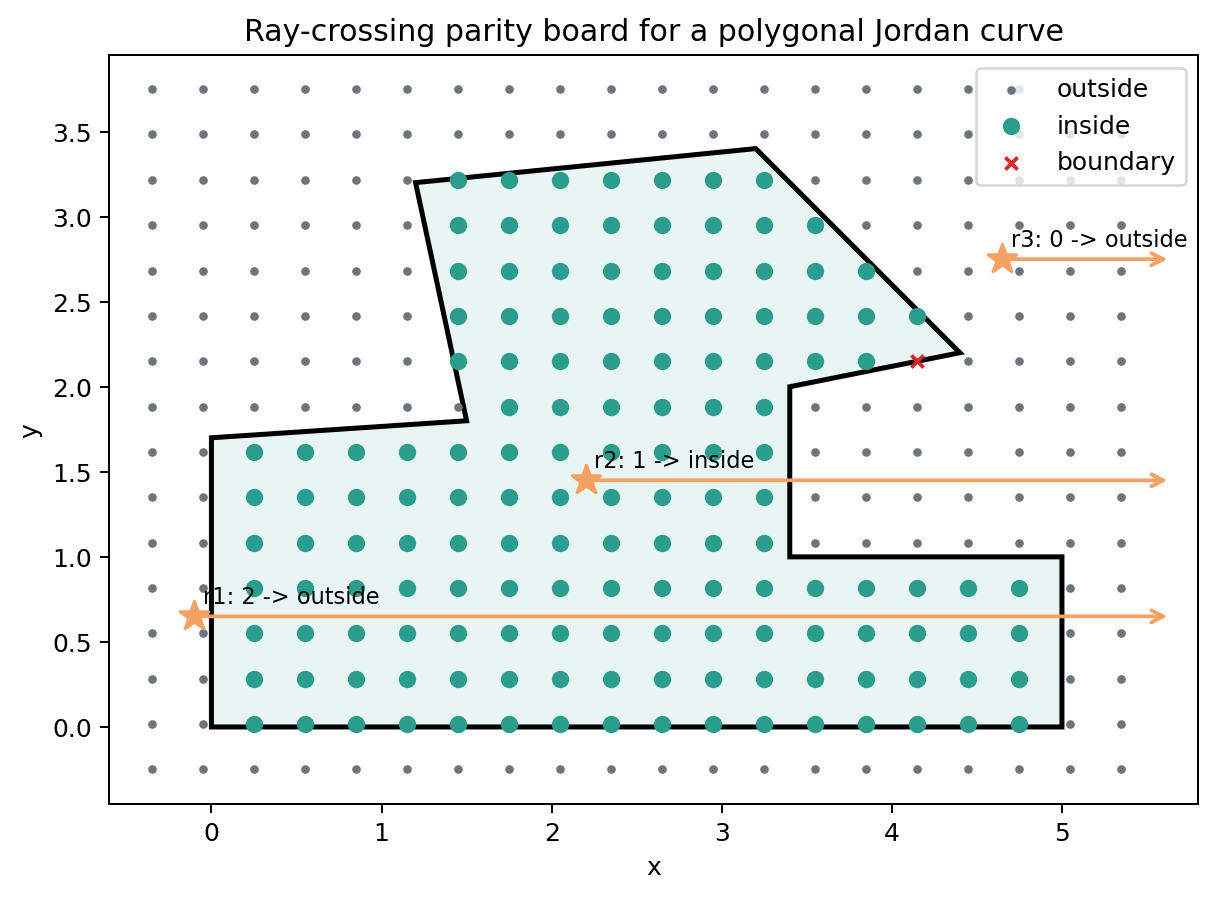

,x,y,status,crossings,inside_by_parity,inside_by_shapely,covered_by_shapely
0,-0.35,-0.25,outside,0,False,False,False
1,-0.05,-0.25,outside,0,False,False,False
2,0.25,-0.25,outside,0,False,False,False
3,0.55,-0.25,outside,0,False,False,False
4,0.85,-0.25,outside,0,False,False,False
5,1.15,-0.25,outside,0,False,False,False
6,1.45,-0.25,outside,0,False,False,False
7,1.75,-0.25,outside,0,False,False,False


Artifact: `artifacts/chapter-01-polygons/checks/ray-crossing-parity-checks.json`

In [3]:
polygon_vertices = np.array([
    (0.0, 0.0),
    (5.0, 0.0),
    (5.0, 1.0),
    (3.4, 1.0),
    (3.4, 2.0),
    (4.4, 2.2),
    (3.2, 3.4),
    (1.2, 3.2),
    (1.5, 1.8),
    (0.0, 1.7),
])
poly = ShapelyPolygon(polygon_vertices)
assert poly.is_valid and poly.exterior.is_ccw


def point_on_segment(p, a, b, tol=1e-10):
    cross = orient(a, b, p)
    if abs(cross) > tol:
        return False
    dot = (p[0] - a[0]) * (p[0] - b[0]) + (p[1] - a[1]) * (p[1] - b[1])
    return dot <= tol


def ray_crossing_status(point, vertices):
    px, py = point
    crossings = 0
    for i, a in enumerate(vertices):
        b = vertices[(i + 1) % len(vertices)]
        if point_on_segment(point, a, b):
            return {"status": "boundary", "crossings": None, "inside": False}
        ay, by = a[1], b[1]
        if (ay > py) != (by > py):
            x_hit = a[0] + (py - ay) * (b[0] - a[0]) / (by - ay)
            if x_hit > px:
                crossings += 1
    return {"status": "inside" if crossings % 2 else "outside", "crossings": crossings, "inside": bool(crossings % 2)}

sample_rows = []
xs = np.linspace(-0.35, 5.35, 20)
ys = np.linspace(-0.25, 3.75, 16)
for y in ys:
    for x in xs:
        p = np.array([float(x), float(y)])
        status = ray_crossing_status(p, polygon_vertices)
        shapely_point = Point(float(x), float(y))
        sample_rows.append({
            "x": round(float(x), 4),
            "y": round(float(y), 4),
            "status": status["status"],
            "crossings": "" if status["crossings"] is None else int(status["crossings"]),
            "inside_by_parity": bool(status["inside"]),
            "inside_by_shapely": bool(poly.contains(shapely_point)),
            "covered_by_shapely": bool(poly.covers(shapely_point)),
        })

parity_matches = all(
    row["inside_by_parity"] == row["inside_by_shapely"]
    for row in sample_rows
    if row["status"] != "boundary"
)
parity_table_path = save_csv(TABLE_DIR / "parity-sample-points.csv", sample_rows)
parity_check_path = save_json(CHECK_DIR / "ray-crossing-parity-checks.json", {
    "sample_count": len(sample_rows),
    "non_boundary_samples": sum(row["status"] != "boundary" for row in sample_rows),
    "parity_matches_shapely_contains": parity_matches,
    "boundary_samples": sum(row["status"] == "boundary" for row in sample_rows),
})

fig, ax = plt.subplots(figsize=(8.4, 5.4))
ax.add_patch(MplPolygon(polygon_vertices, closed=True, facecolor=palette["fill"], edgecolor="black", linewidth=2))
for status_name, color, marker in [("outside", palette["outside"], "."), ("inside", palette["inside"], "o"), ("boundary", palette["boundary"], "x")]:
    pts = np.array([(row["x"], row["y"]) for row in sample_rows if row["status"] == status_name], dtype=float)
    if len(pts):
        ax.scatter(pts[:, 0], pts[:, 1], s=35 if status_name == "inside" else 24, c=color, marker=marker, label=status_name)

probe_points = [np.array([-0.1, 0.65]), np.array([2.2, 1.45]), np.array([4.65, 2.75])]
for idx, point in enumerate(probe_points, start=1):
    status = ray_crossing_status(point, polygon_vertices)
    ax.plot(point[0], point[1], marker="*", color="#f4a261", markersize=13, zorder=4)
    ax.add_patch(FancyArrowPatch((point[0], point[1]), (5.65, point[1]), arrowstyle="->", mutation_scale=12, color="#f4a261", linewidth=1.5))
    ax.text(point[0] + 0.05, point[1] + 0.08, f"r{idx}: {status['crossings']} -> {status['status']}", fontsize=9)

ax.set_title("Ray-crossing parity board for a polygonal Jordan curve")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.6, 5.8)
ax.set_ylim(-0.45, 3.95)
ax.legend(loc="upper right")
ax.set_xlabel("x")
ax.set_ylabel("y")
parity_fig_path = save_figure(fig, FIG_DIR / "ray-crossing-parity-board.png")

display_artifact(parity_fig_path)
display(pd.DataFrame(sample_rows).head(8))
display_artifact(parity_check_path)
assert parity_matches


## 2. Diagonals, Ears, And Triangulation Counts

A diagonal is not just any segment between vertices. It must stay inside the polygon except at its endpoints. The ear-clipping routine below makes the existence proof executable: find a convex ear, add the diagonal connecting its neighbors, remove the ear tip, and repeat. The resulting ledger checks both the local construction and the global counts.


Artifact: `artifacts/chapter-01-polygons/figures/ear-triangulation-diagonals.png`

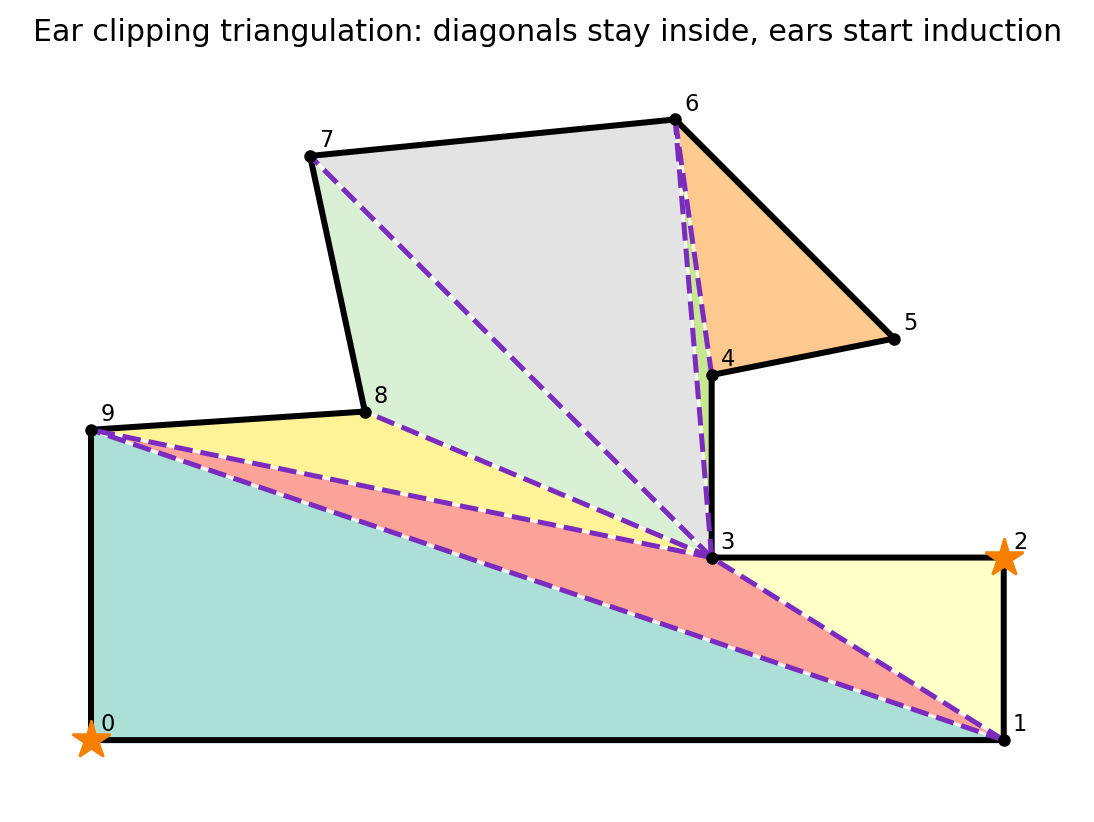

,vertices,triangles_in_any_triangulation,diagonals_in_any_triangulation,euler_check_V_minus_E_plus_F
0,3,1,0,2
1,4,2,1,2
2,5,3,2,2
3,6,4,3,2
4,7,5,4,2
5,8,6,5,2
6,9,7,6,2
7,10,8,7,2
8,11,9,8,2
9,12,10,9,2


Artifact: `artifacts/chapter-01-polygons/checks/triangulation-invariants.json`

In [4]:
def original_adjacent(i, j, n):
    return abs(i - j) == 1 or abs(i - j) == n - 1


def segment_clear_inside(vertices, i, j, working):
    seg = LineString([vertices[i], vertices[j]])
    current_poly = ShapelyPolygon([vertices[k] for k in working])
    if not current_poly.covers(seg):
        return False
    for a, b in zip(working, working[1:] + working[:1]):
        if a in (i, j) or b in (i, j):
            continue
        edge = LineString([vertices[a], vertices[b]])
        if not seg.intersection(edge).is_empty:
            return False
    return True


def is_ear(vertices, working, pos):
    a = working[pos - 1]
    b = working[pos]
    c = working[(pos + 1) % len(working)]
    if orient(vertices[a], vertices[b], vertices[c]) <= 1e-10:
        return False
    if not segment_clear_inside(vertices, a, c, working):
        return False
    ear_triangle = ShapelyPolygon([vertices[a], vertices[b], vertices[c]])
    for k in working:
        if k in (a, b, c):
            continue
        if ear_triangle.buffer(1e-10).covers(Point(vertices[k])):
            return False
    return True


def ear_clip(vertices):
    vertices = [tuple(map(float, p)) for p in vertices]
    if not ShapelyPolygon(vertices).exterior.is_ccw:
        vertices = list(reversed(vertices))
    n = len(vertices)
    working = list(range(n))
    triangles = []
    ears = []
    diagonals = set()
    while len(working) > 3:
        for pos in range(len(working)):
            if is_ear(vertices, working, pos):
                a = working[pos - 1]
                b = working[pos]
                c = working[(pos + 1) % len(working)]
                triangles.append((a, b, c))
                ears.append((a, b, c))
                if not original_adjacent(a, c, n):
                    diagonals.add(tuple(sorted((a, c))))
                del working[pos]
                break
        else:
            raise RuntimeError(f"No ear found in working cycle {working}")
    final_triangle = tuple(working)
    triangles.append(final_triangle)
    return vertices, triangles, sorted(diagonals), ears, final_triangle

vertices, triangles, diagonals, ears, final_triangle = ear_clip(polygon_vertices)
n = len(vertices)
polygon_area = abs(signed_area(vertices))
tri_area_sum = sum(triangle_area(np.array(vertices[a]), np.array(vertices[b]), np.array(vertices[c])) for a, b, c in triangles)
E = n + len(diagonals)
F = len(triangles) + 1
triangulation_checks = {
    "vertices": n,
    "triangles": len(triangles),
    "expected_triangles": n - 2,
    "diagonals": len(diagonals),
    "expected_diagonals": n - 3,
    "euler_V_minus_E_plus_F": n - E + F,
    "polygon_area": polygon_area,
    "triangle_area_sum": tri_area_sum,
    "area_residual": abs(polygon_area - tri_area_sum),
    "first_two_ears": [list(ear) for ear in ears[:2]],
}
triangulation_check_path = save_json(CHECK_DIR / "triangulation-invariants.json", triangulation_checks)
count_rows = []
for k in range(3, 13):
    count_rows.append({
        "vertices": k,
        "triangles_in_any_triangulation": k - 2,
        "diagonals_in_any_triangulation": k - 3,
        "euler_check_V_minus_E_plus_F": k - (k + (k - 3)) + ((k - 2) + 1),
    })
count_table_path = save_csv(TABLE_DIR / "triangulation-counts.csv", count_rows)

fig, ax = plt.subplots(figsize=(8.2, 5.4))
colors = plt.cm.Set3(np.linspace(0, 1, len(triangles)))
for color, tri in zip(colors, triangles):
    coords = np.array([vertices[i] for i in tri])
    ax.add_patch(MplPolygon(coords, closed=True, facecolor=color, edgecolor="#ffffff", linewidth=1.2, alpha=0.72))
ax.add_patch(MplPolygon(vertices, closed=True, facecolor="none", edgecolor="black", linewidth=2.4))
for a, b in diagonals:
    xy = np.array([vertices[a], vertices[b]])
    ax.plot(xy[:, 0], xy[:, 1], color=palette["diagonal"], linewidth=2.0, linestyle="--")
for idx, (x, y) in enumerate(vertices):
    ax.plot(x, y, "ko", markersize=4)
    ax.text(x + 0.05, y + 0.05, str(idx), fontsize=9)
for a, b, c in ears[:2]:
    ax.plot(vertices[b][0], vertices[b][1], marker="*", color="#f77f00", markersize=16, zorder=5)
ax.set_title("Ear clipping triangulation: diagonals stay inside, ears start induction")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.4, 5.4)
ax.set_ylim(-0.35, 3.75)
ax.axis("off")
triangulation_fig_path = save_figure(fig, FIG_DIR / "ear-triangulation-diagonals.png")

display_artifact(triangulation_fig_path)
display(pd.DataFrame(count_rows))
display_artifact(triangulation_check_path)
assert len(triangles) == n - 2
assert len(diagonals) == n - 3
assert n - E + F == 2
assert abs(polygon_area - tri_area_sum) < 1e-9


## 3. Convex Polygon Triangulations And Catalan Growth

For a convex polygon every nonadjacent pair of vertices is a diagonal, so shape no longer suppresses possible triangulations. The number for a polygon with `m + 2` vertices is the Catalan number

`C_m = (1 / (m + 1)) * binomial(2m, m)`.

The dynamic program below computes the same numbers through the recurrence `C_m = sum C_i C_{m-1-i}`. The recurrence is the computational version of choosing the triangle incident to a fixed boundary edge.


Artifact: `artifacts/chapter-01-polygons/html/catalan-triangulation-growth.html`

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


Artifact: `artifacts/chapter-01-polygons/figures/catalan-triangulation-growth.png`

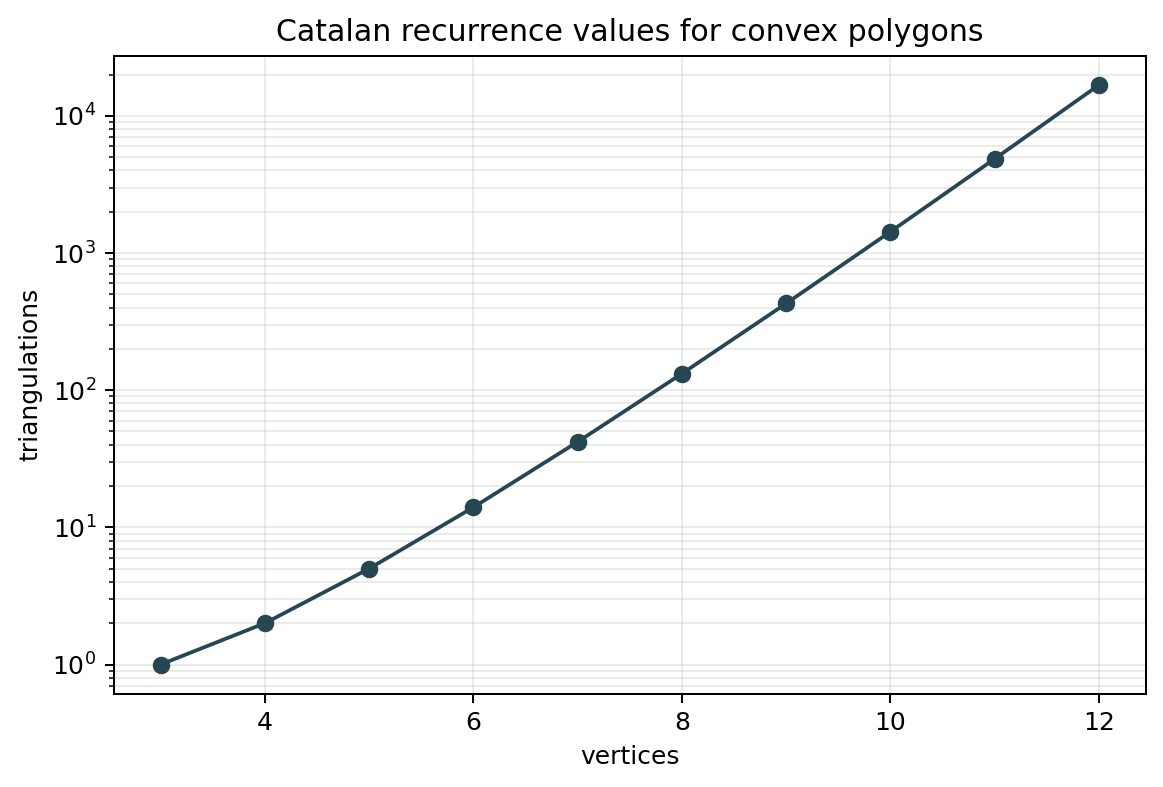

,vertices_in_convex_polygon,catalan_index_m,triangulations,closed_form,recurrence_matches_closed_form
0,3,1,1,1,True
1,4,2,2,2,True
2,5,3,5,5,True
3,6,4,14,14,True
4,7,5,42,42,True
5,8,6,132,132,True
6,9,7,429,429,True
7,10,8,1430,1430,True
8,11,9,4862,4862,True
9,12,10,16796,16796,True


Artifact: `artifacts/chapter-01-polygons/checks/catalan-recurrence-checks.json`

In [5]:
def catalan_numbers(max_m):
    values = [1]
    for m in range(1, max_m + 1):
        values.append(sum(values[i] * values[m - 1 - i] for i in range(m)))
    return values

max_m = 10
catalan = catalan_numbers(max_m)
catalan_rows = []
closed_form_matches = True
for vertices_count in range(3, max_m + 3):
    m = vertices_count - 2
    closed = math.comb(2 * m, m) // (m + 1)
    recurrence_value = catalan[m]
    closed_form_matches = closed_form_matches and (closed == recurrence_value)
    catalan_rows.append({
        "vertices_in_convex_polygon": vertices_count,
        "catalan_index_m": m,
        "triangulations": recurrence_value,
        "closed_form": closed,
        "recurrence_matches_closed_form": closed == recurrence_value,
    })

catalan_table_path = save_csv(TABLE_DIR / "catalan-triangulations.csv", catalan_rows)
catalan_check_path = save_json(CHECK_DIR / "catalan-recurrence-checks.json", {
    "max_catalan_index": max_m,
    "closed_form_matches_recurrence": closed_form_matches,
    "C_1_triangle": catalan[1],
    "C_2_quadrilateral": catalan[2],
    "C_6_octagon": catalan[6],
})

plotly_fig = go.Figure()
plotly_fig.add_trace(go.Bar(
    x=[row["vertices_in_convex_polygon"] for row in catalan_rows],
    y=[row["triangulations"] for row in catalan_rows],
    marker_color="#2a9d8f",
    name="triangulations",
    hovertemplate="vertices=%{x}<br>triangulations=%{y}<extra></extra>",
))
plotly_fig.update_layout(
    title="Catalan growth for convex polygon triangulations",
    xaxis_title="vertices",
    yaxis_title="number of triangulations (log scale)",
    yaxis_type="log",
    template="plotly_white",
    height=430,
)
catalan_html_path = register(HTML_DIR / "catalan-triangulation-growth.html")
plotly_fig.write_html(str(catalan_html_path), include_plotlyjs="inline", full_html=True)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot([row["vertices_in_convex_polygon"] for row in catalan_rows], [row["triangulations"] for row in catalan_rows], marker="o", color="#264653")
ax.set_yscale("log")
ax.set_xlabel("vertices")
ax.set_ylabel("triangulations")
ax.set_title("Catalan recurrence values for convex polygons")
ax.grid(True, which="both", alpha=0.25)
catalan_png_path = save_figure(fig, FIG_DIR / "catalan-triangulation-growth.png")

display_artifact(catalan_html_path)
display_artifact(catalan_png_path)
display(pd.DataFrame(catalan_rows))
display_artifact(catalan_check_path)
assert closed_form_matches
assert catalan[6] == 132


## 4. Art Gallery Theorem Through Fisk 3-Coloring

A triangulation turns a polygon into a graph: boundary edges plus diagonals. Reverse the ear-removal order and each deleted ear tip can be colored by the one color not used by its two neighbors. Every triangle then has all three colors. The least frequent color appears at most `floor(n/3)` times, and placing guards at those vertices covers every triangle.


Artifact: `artifacts/chapter-01-polygons/figures/art-gallery-3-color-guards.png`

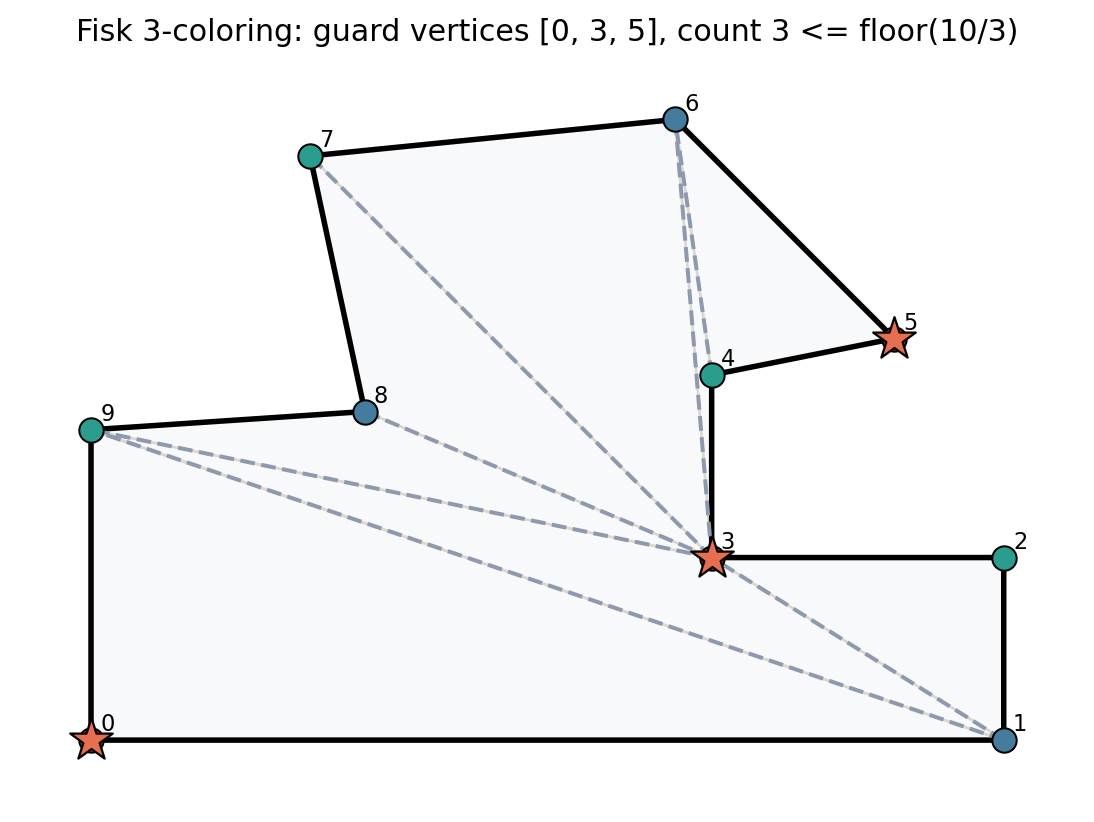

,vertices,proper_three_coloring,color_counts,least_color,guards,guard_count,floor_n_over_3,guard_count_within_bound,every_triangle_has_a_guard
0,10,True,"{'red': 3, 'blue': 3, 'green': 4}",red,"[0, 3, 5]",3,3,True,True


Artifact: `artifacts/chapter-01-polygons/checks/art-gallery-guard-checks.json`

In [6]:
def triangulation_graph(n, diagonals):
    graph = nx.Graph()
    graph.add_nodes_from(range(n))
    graph.add_edges_from((i, (i + 1) % n) for i in range(n))
    graph.add_edges_from(diagonals)
    return graph


def color_from_ears(n, ears, final_triangle):
    colors = {final_triangle[0]: 0, final_triangle[1]: 1, final_triangle[2]: 2}
    for a, b, c in reversed(ears):
        missing = {0, 1, 2} - {colors[a], colors[c]}
        colors[b] = missing.pop()
    return colors

color_names = {0: "red", 1: "blue", 2: "green"}
color_values = {0: "#d62828", 1: "#457b9d", 2: "#2a9d8f"}
T_graph = triangulation_graph(n, diagonals)
vertex_colors = color_from_ears(n, ears, final_triangle)
proper_coloring = all(vertex_colors[a] != vertex_colors[b] for a, b in T_graph.edges)
color_counts = {c: sum(value == c for value in vertex_colors.values()) for c in [0, 1, 2]}
least_color = min(color_counts, key=color_counts.get)
guard_vertices = sorted([v for v, color in vertex_colors.items() if color == least_color])
every_triangle_guarded = all(any(v in guard_vertices for v in tri) for tri in triangles)
guard_bound = n // 3

guard_checks = {
    "vertices": n,
    "proper_three_coloring": proper_coloring,
    "color_counts": {color_names[k]: int(v) for k, v in color_counts.items()},
    "least_color": color_names[least_color],
    "guards": guard_vertices,
    "guard_count": len(guard_vertices),
    "floor_n_over_3": guard_bound,
    "guard_count_within_bound": len(guard_vertices) <= guard_bound,
    "every_triangle_has_a_guard": every_triangle_guarded,
}
guard_check_path = save_json(CHECK_DIR / "art-gallery-guard-checks.json", guard_checks)

fig, ax = plt.subplots(figsize=(8.2, 5.4))
for tri in triangles:
    coords = np.array([vertices[i] for i in tri])
    ax.add_patch(MplPolygon(coords, closed=True, facecolor="#f8f9fa", edgecolor="#dad7cd", linewidth=1.0))
for a, b in diagonals:
    xy = np.array([vertices[a], vertices[b]])
    ax.plot(xy[:, 0], xy[:, 1], color="#8d99ae", linewidth=1.6, linestyle="--")
ax.add_patch(MplPolygon(vertices, closed=True, facecolor="none", edgecolor="black", linewidth=2.2))
for idx, (x, y) in enumerate(vertices):
    color = color_values[vertex_colors[idx]]
    ax.scatter([x], [y], s=95, c=color, edgecolors="black", linewidths=0.8, zorder=4)
    ax.text(x + 0.05, y + 0.05, str(idx), fontsize=9)
for v in guard_vertices:
    x, y = vertices[v]
    ax.scatter([x], [y], s=320, marker="*", c=palette["guard"], edgecolors="black", linewidths=0.9, zorder=5)
ax.set_title(f"Fisk 3-coloring: guard vertices {guard_vertices}, count {len(guard_vertices)} <= floor({n}/3)")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-0.4, 5.4)
ax.set_ylim(-0.35, 3.75)
ax.axis("off")
guard_fig_path = save_figure(fig, FIG_DIR / "art-gallery-3-color-guards.png")

display_artifact(guard_fig_path)
display(pd.DataFrame([guard_checks]))
display_artifact(guard_check_path)
assert proper_coloring
assert every_triangle_guarded
assert len(guard_vertices) <= guard_bound


## 5. Orthogonal Gallery And Fortress Variants

Changing the problem changes the invariant. Orthogonal galleries restrict every corner to a right angle and improve the sufficient and sometimes necessary vertex-guard bound to `floor(n/4)`. Fortress visibility asks guards on the boundary to cover the exterior, where the tight bound rises to `ceil(n/2)`. The diagrams below are not proofs; they are a formula and scenario ledger to keep the variants distinct from Fisk's theorem.


Artifact: `artifacts/chapter-01-polygons/figures/gallery-variant-bounds.png`

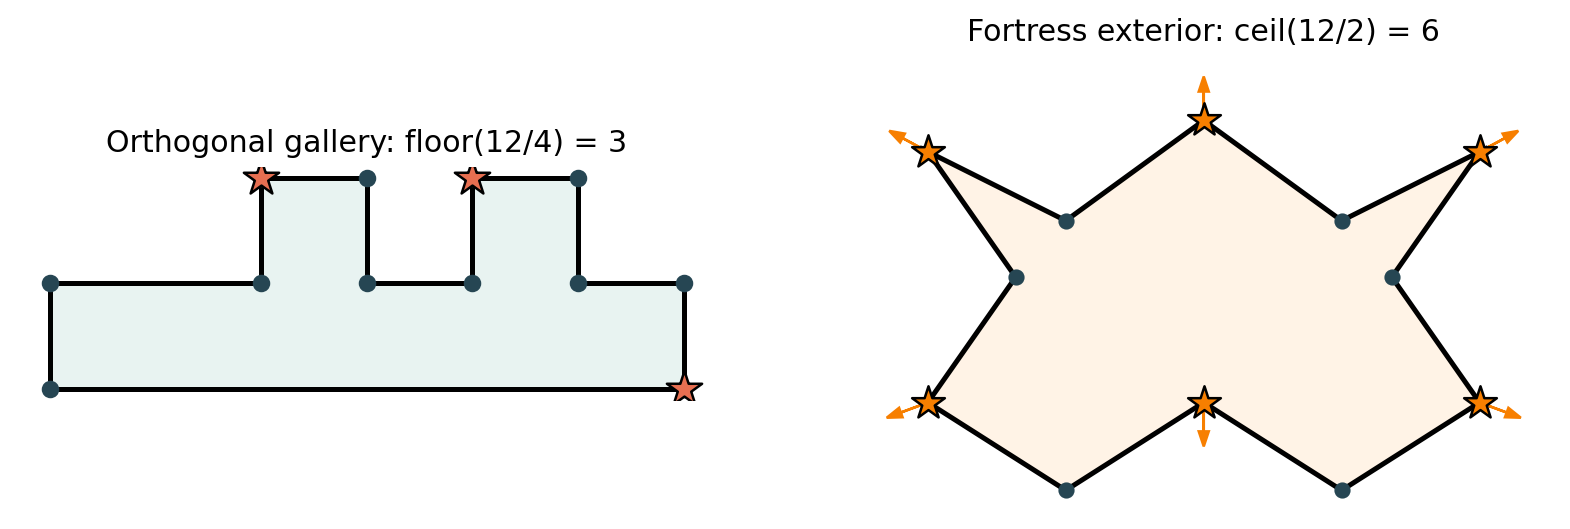

,variant,setting,bound,example_vertices,example_bound
0,classical art gallery,"arbitrary simple polygon, interior coverage by...",floor(n/3),10,3
1,orthogonal gallery,"right-angled polygon, interior coverage",floor(n/4),12,3
2,fortress,polygon exterior covered by boundary guards,ceil(n/2),12,6


Artifact: `artifacts/chapter-01-polygons/checks/gallery-variant-bounds.json`

In [7]:
orthogonal_vertices = np.array([
    (0.0, 0.0), (6.0, 0.0), (6.0, 1.0), (5.0, 1.0),
    (5.0, 2.0), (4.0, 2.0), (4.0, 1.0), (3.0, 1.0),
    (3.0, 2.0), (2.0, 2.0), (2.0, 1.0), (0.0, 1.0),
])
fortress_vertices = np.array([
    (0.0, 0.0), (1.1, -0.7), (2.2, 0.0), (3.3, -0.7),
    (4.4, 0.0), (3.7, 1.0), (4.4, 2.0), (3.3, 1.45),
    (2.2, 2.25), (1.1, 1.45), (0.0, 2.0), (0.7, 1.0),
])
assert ShapelyPolygon(orthogonal_vertices).is_valid
assert ShapelyPolygon(fortress_vertices).is_valid

variant_rows = [
    {
        "variant": "classical art gallery",
        "setting": "arbitrary simple polygon, interior coverage by vertex guards",
        "bound": "floor(n/3)",
        "example_vertices": n,
        "example_bound": n // 3,
    },
    {
        "variant": "orthogonal gallery",
        "setting": "right-angled polygon, interior coverage",
        "bound": "floor(n/4)",
        "example_vertices": len(orthogonal_vertices),
        "example_bound": len(orthogonal_vertices) // 4,
    },
    {
        "variant": "fortress",
        "setting": "polygon exterior covered by boundary guards",
        "bound": "ceil(n/2)",
        "example_vertices": len(fortress_vertices),
        "example_bound": math.ceil(len(fortress_vertices) / 2),
    },
]
variant_table_path = save_csv(TABLE_DIR / "gallery-variant-bounds.csv", variant_rows)
variant_check_path = save_json(CHECK_DIR / "gallery-variant-bounds.json", {
    "classical_bound_for_working_polygon": n // 3,
    "orthogonal_example_vertices": len(orthogonal_vertices),
    "orthogonal_floor_n_over_4": len(orthogonal_vertices) // 4,
    "fortress_example_vertices": len(fortress_vertices),
    "fortress_ceil_n_over_2": math.ceil(len(fortress_vertices) / 2),
    "orthogonal_polygon_valid": bool(ShapelyPolygon(orthogonal_vertices).is_valid),
    "fortress_polygon_valid": bool(ShapelyPolygon(fortress_vertices).is_valid),
})

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
ax = axs[0]
ax.add_patch(MplPolygon(orthogonal_vertices, closed=True, facecolor="#e8f3f1", edgecolor="black", linewidth=2))
for i, (x, y) in enumerate(orthogonal_vertices):
    ax.scatter([x], [y], c="#264653", s=36)
    if i in [1, 5, 9]:
        ax.scatter([x], [y], marker="*", s=220, c=palette["guard"], edgecolors="black", zorder=4)
ax.set_title(f"Orthogonal gallery: floor({len(orthogonal_vertices)}/4) = {len(orthogonal_vertices)//4}")
ax.set_aspect("equal")
ax.axis("off")

ax = axs[1]
ax.add_patch(MplPolygon(fortress_vertices, closed=True, facecolor="#fff3e6", edgecolor="black", linewidth=2))
centroid = fortress_vertices.mean(axis=0)
for i, (x, y) in enumerate(fortress_vertices):
    if i % 2 == 0:
        ax.scatter([x], [y], marker="*", s=190, c="#f77f00", edgecolors="black", zorder=4)
        direction = np.array([x, y]) - centroid
        direction = direction / np.linalg.norm(direction)
        ax.arrow(x, y, 0.35 * direction[0], 0.35 * direction[1], head_width=0.08, color="#f77f00", length_includes_head=True)
    else:
        ax.scatter([x], [y], c="#264653", s=30)
ax.set_title(f"Fortress exterior: ceil({len(fortress_vertices)}/2) = {math.ceil(len(fortress_vertices)/2)}")
ax.set_aspect("equal")
ax.axis("off")
variant_fig_path = save_figure(fig, FIG_DIR / "gallery-variant-bounds.png")

display_artifact(variant_fig_path)
display(pd.DataFrame(variant_rows))
display_artifact(variant_check_path)
assert variant_rows[1]["example_bound"] == 3
assert variant_rows[2]["example_bound"] == 6


## 6. Two-Dimensional Scissors Congruence As An Area Ledger

The Wallace-Bolyai-Gerwien theorem says equal area is enough for polygonal scissors congruence in the plane. A constructive proof triangulates a polygon, turns each triangle into a rectangle of the same area, and stacks those rectangles into one common rectangle. This cell records the bookkeeping version of that proof for our polygon.


Artifact: `artifacts/chapter-01-polygons/figures/scissors-area-ledger.png`

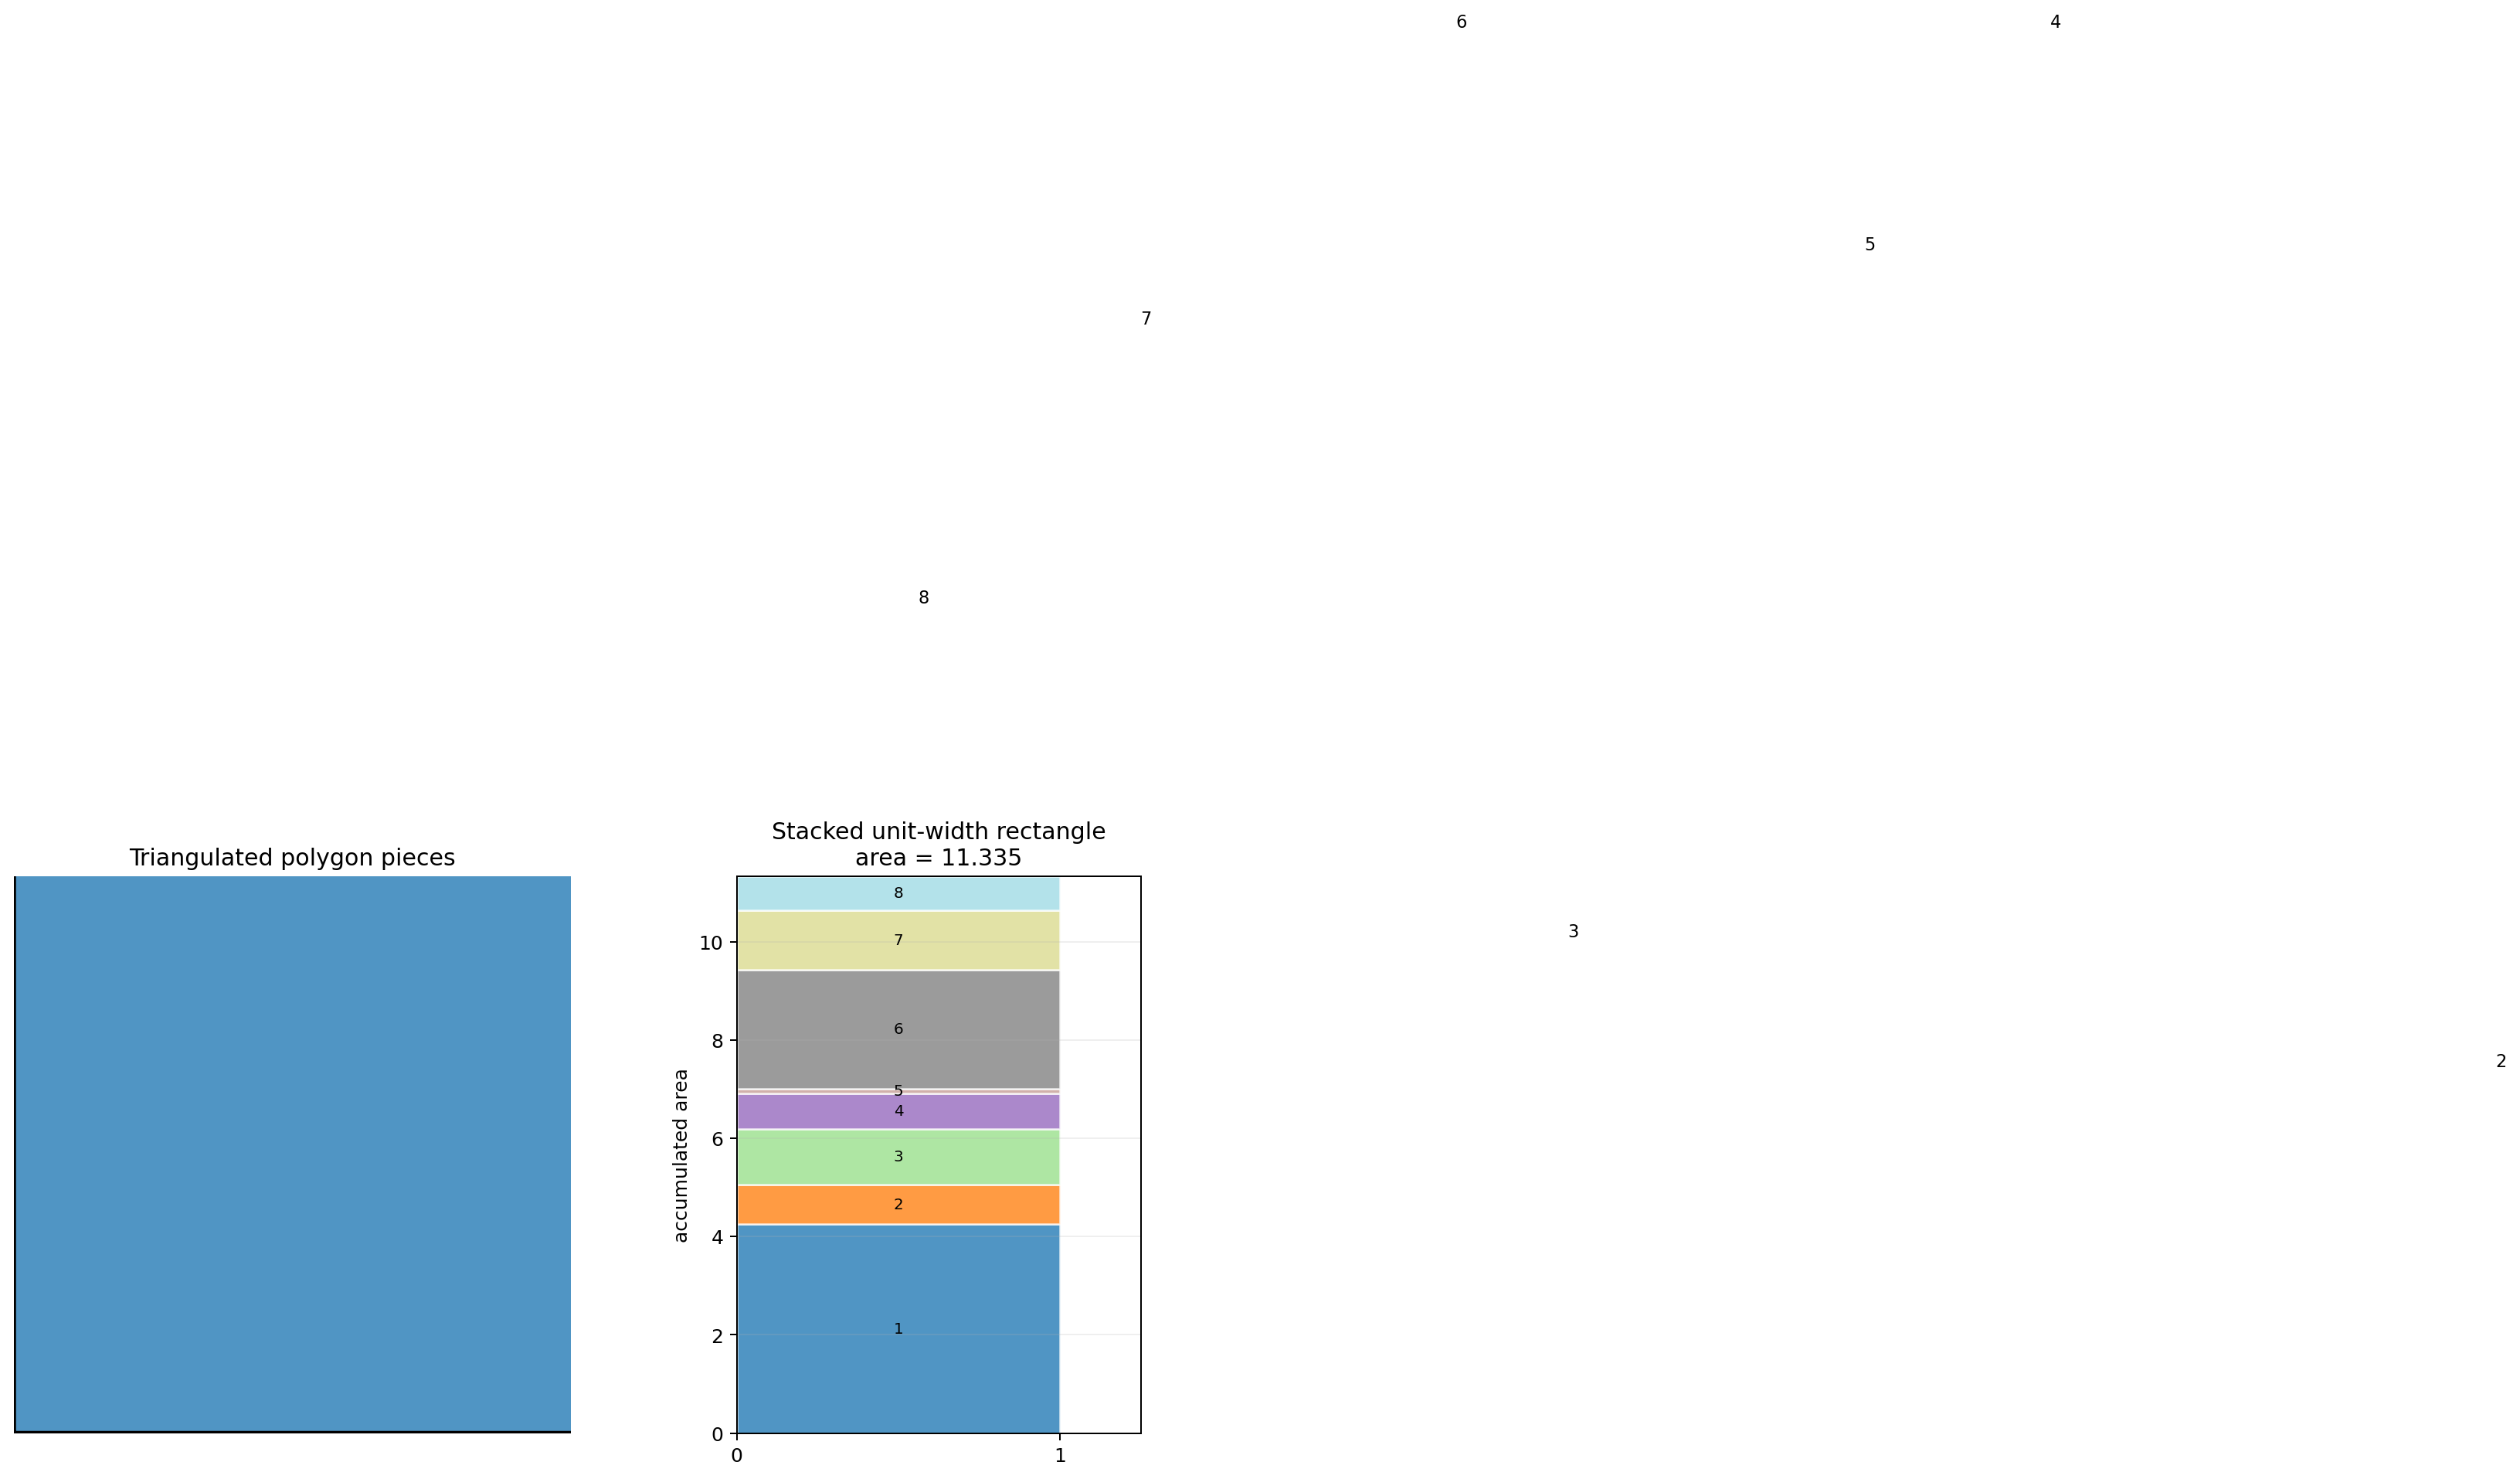

,piece,triangle_vertices,triangle_area,chosen_base_length,triangle_altitude_to_base,unit_rectangle_width,unit_rectangle_height,unit_rectangle_area
0,1,9-0-1,4.250,1.7000,5.0000,1.0,4.250,4.250
1,2,1-2-3,0.800,1.0000,1.6000,1.0,0.800,0.800
2,3,9-1-3,1.140,5.2811,0.4317,1.0,1.140,1.140
3,4,4-5-6,0.720,1.0198,1.4120,1.0,0.720,0.720
4,5,3-4-6,0.100,1.0000,0.2000,1.0,0.100,0.100
5,6,3-6-7,2.420,2.4083,2.0097,1.0,2.420,2.420
6,7,3-7-8,1.210,3.1113,0.7778,1.0,1.210,1.210
7,8,3-8-9,0.695,2.0616,0.6742,1.0,0.695,0.695


Artifact: `artifacts/chapter-01-polygons/checks/scissors-area-checks.json`

In [8]:
scissors_rows = []
for piece_id, tri in enumerate(triangles, start=1):
    coords = np.array([vertices[i] for i in tri], dtype=float)
    area = triangle_area(coords[0], coords[1], coords[2])
    base = float(np.linalg.norm(coords[1] - coords[0]))
    altitude = 2 * area / base if base > 0 else float("nan")
    scissors_rows.append({
        "piece": piece_id,
        "triangle_vertices": "-".join(map(str, tri)),
        "triangle_area": area,
        "chosen_base_length": base,
        "triangle_altitude_to_base": altitude,
        "unit_rectangle_width": 1.0,
        "unit_rectangle_height": area,
        "unit_rectangle_area": area,
    })

scissors_total_area = sum(row["triangle_area"] for row in scissors_rows)
scissors_table_path = save_csv(TABLE_DIR / "scissors-area-ledger.csv", scissors_rows)
scissors_check_path = save_json(CHECK_DIR / "scissors-area-checks.json", {
    "polygon_area": polygon_area,
    "sum_triangle_areas": scissors_total_area,
    "sum_unit_rectangle_areas": sum(row["unit_rectangle_area"] for row in scissors_rows),
    "area_residual": abs(polygon_area - scissors_total_area),
    "piece_count_from_triangulation": len(scissors_rows),
})

fig, axs = plt.subplots(1, 2, figsize=(11, 5.2), gridspec_kw={"width_ratios": [1.25, 0.75]})
ax = axs[0]
colors = plt.cm.tab20(np.linspace(0, 1, len(triangles)))
for color, tri, row in zip(colors, triangles, scissors_rows):
    coords = np.array([vertices[i] for i in tri])
    ax.add_patch(MplPolygon(coords, closed=True, facecolor=color, edgecolor="white", linewidth=1.0, alpha=0.78))
    center = coords.mean(axis=0)
    ax.text(center[0], center[1], str(row["piece"]), ha="center", va="center", fontsize=9)
ax.add_patch(MplPolygon(vertices, closed=True, facecolor="none", edgecolor="black", linewidth=2.2))
ax.set_title("Triangulated polygon pieces")
ax.set_aspect("equal")
ax.axis("off")

ax = axs[1]
y0 = 0.0
for color, row in zip(colors, scissors_rows):
    h = row["unit_rectangle_height"]
    ax.add_patch(Rectangle((0, y0), 1.0, h, facecolor=color, edgecolor="white", linewidth=1.0, alpha=0.78))
    ax.text(0.5, y0 + h / 2, str(row["piece"]), ha="center", va="center", fontsize=8)
    y0 += h
ax.set_xlim(0, 1.25)
ax.set_ylim(0, y0)
ax.set_title(f"Stacked unit-width rectangle\narea = {y0:.3f}")
ax.set_xticks([0, 1])
ax.set_ylabel("accumulated area")
ax.grid(axis="y", alpha=0.2)
scissors_fig_path = save_figure(fig, FIG_DIR / "scissors-area-ledger.png")

display_artifact(scissors_fig_path)
display(pd.DataFrame(scissors_rows).round(4))
display_artifact(scissors_check_path)
assert abs(polygon_area - scissors_total_area) < 1e-9


## 7. Three-Dimensional Scissors Congruence And The Dehn Obstruction

In 3D, equal volume is not enough. The chapter's obstruction compares two tetrahedra with congruent bases and equal heights. One tetrahedron has dihedral angles that are rational multiples of `pi`; the other has three edges with dihedral angle `arctan(sqrt(2))`. Bricard's mass equation forces positive integer combinations of original dihedral angles, plus multiples of `pi`, to agree under scissors congruence. That cannot happen here because `arctan(sqrt(2)) / pi` is irrational.


Artifact: `artifacts/chapter-01-polygons/figures/dehn-dihedral-ledger.png`

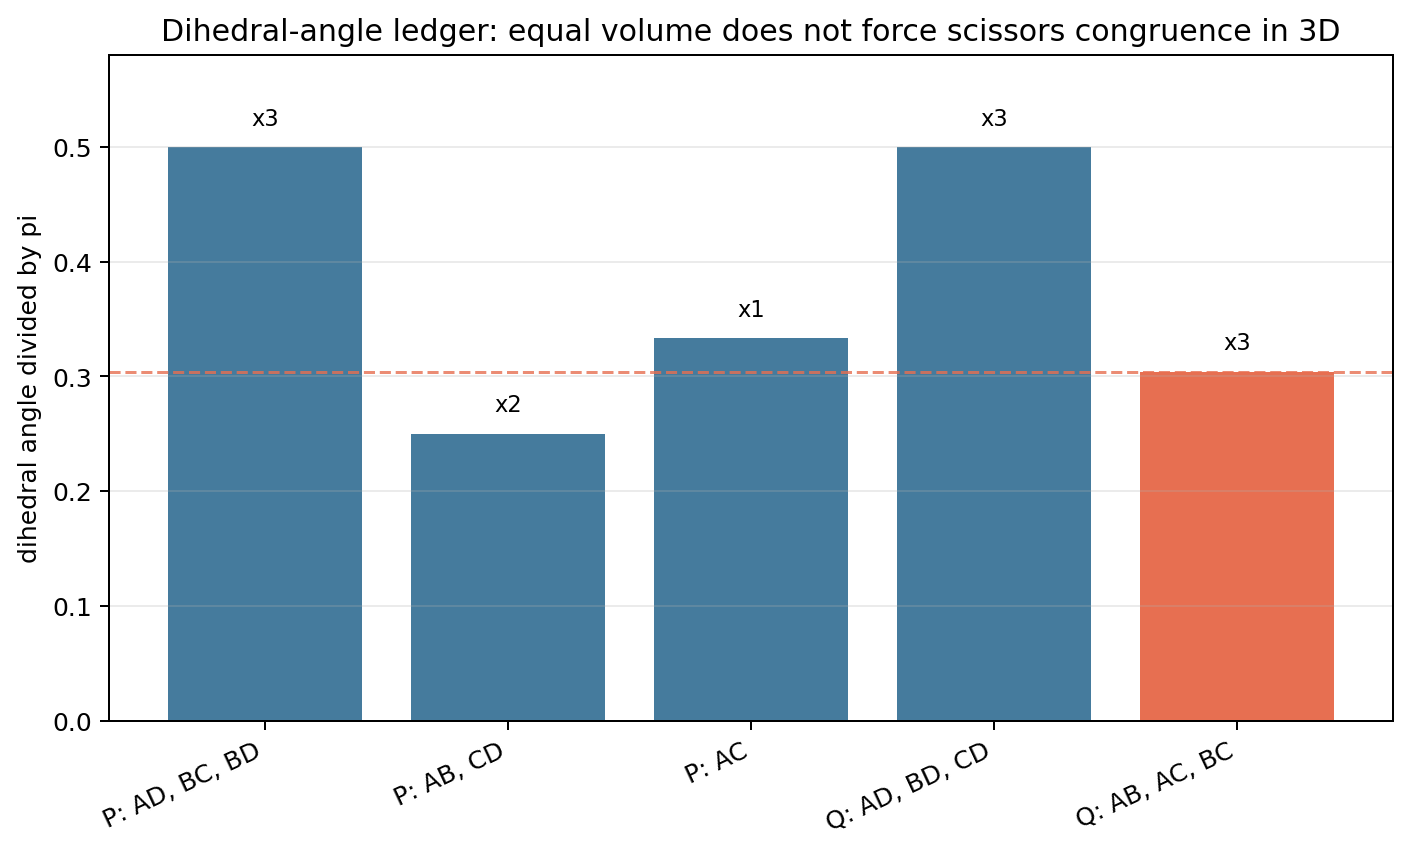

,solid,edge_family,edge_count,angle_expression,angle_over_pi_numeric,rational_multiple_of_pi
0,P rational tetrahedron,"AD, BC, BD",3,pi/2,0.500000,True
1,P rational tetrahedron,"AB, CD",2,pi/4,0.250000,True
2,P rational tetrahedron,AC,1,pi/3,0.333333,True
3,Q irrational tetrahedron,"AD, BD, CD",3,pi/2,0.500000,True
4,Q irrational tetrahedron,"AB, AC, BC",3,atan(sqrt(2)),0.304087,False


Artifact: `artifacts/chapter-01-polygons/checks/dehn-ledger-checks.json`

In [9]:
pi = sp.pi
theta = sp.atan(sp.sqrt(2))
P_angle_rows = [
    {"solid": "P rational tetrahedron", "edge_family": "AD, BC, BD", "edge_count": 3, "angle_expression": "pi/2", "angle_over_pi_numeric": 0.5, "rational_multiple_of_pi": True},
    {"solid": "P rational tetrahedron", "edge_family": "AB, CD", "edge_count": 2, "angle_expression": "pi/4", "angle_over_pi_numeric": 0.25, "rational_multiple_of_pi": True},
    {"solid": "P rational tetrahedron", "edge_family": "AC", "edge_count": 1, "angle_expression": "pi/3", "angle_over_pi_numeric": 1 / 3, "rational_multiple_of_pi": True},
]
Q_angle_rows = [
    {"solid": "Q irrational tetrahedron", "edge_family": "AD, BD, CD", "edge_count": 3, "angle_expression": "pi/2", "angle_over_pi_numeric": 0.5, "rational_multiple_of_pi": True},
    {"solid": "Q irrational tetrahedron", "edge_family": "AB, AC, BC", "edge_count": 3, "angle_expression": "atan(sqrt(2))", "angle_over_pi_numeric": float(theta / pi), "rational_multiple_of_pi": False},
]
dehn_rows = P_angle_rows + Q_angle_rows
dehlike_table_path = save_csv(TABLE_DIR / "dehn-dihedral-ledger.csv", dehn_rows)

ratio = float(theta / pi)
best_small_fraction = Fraction(ratio).limit_denominator(80)
small_denominator_screen_passed = abs(ratio - float(best_small_fraction)) > 1e-8
P_weighted_angle_over_pi = sum(row["edge_count"] * row["angle_over_pi_numeric"] for row in P_angle_rows)
Q_rational_part_over_pi = Q_angle_rows[0]["edge_count"] * Q_angle_rows[0]["angle_over_pi_numeric"]

dehn_check_path = save_json(CHECK_DIR / "dehn-ledger-checks.json", {
    "equal_volume_by_congruent_base_and_height": True,
    "P_all_angles_rational_multiples_of_pi": all(row["rational_multiple_of_pi"] for row in P_angle_rows),
    "Q_contains_atan_sqrt2_angle": True,
    "atan_sqrt2_over_pi_numeric": ratio,
    "best_fraction_with_denominator_at_most_80": str(best_small_fraction),
    "small_denominator_rational_screen_passed": small_denominator_screen_passed,
    "P_weighted_boundary_angle_sum_over_pi": P_weighted_angle_over_pi,
    "Q_rational_edge_weighted_part_over_pi": Q_rational_part_over_pi,
    "obstruction_statement": "Assuming atan(sqrt(2))/pi is irrational, Bricard's required positive-integer angle equation cannot hold.",
})

fig, ax = plt.subplots(figsize=(9.2, 4.8))
labels = [f"{row['solid'].split()[0]}: {row['edge_family']}" for row in dehn_rows]
values = [row["angle_over_pi_numeric"] for row in dehn_rows]
counts = [row["edge_count"] for row in dehn_rows]
bar_colors = ["#457b9d" if row["rational_multiple_of_pi"] else "#e76f51" for row in dehn_rows]
bars = ax.bar(range(len(dehn_rows)), values, color=bar_colors)
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015, f"x{count}", ha="center", va="bottom", fontsize=9)
ax.axhline(ratio, color="#e76f51", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("dihedral angle divided by pi")
ax.set_ylim(0, 0.58)
ax.set_title("Dihedral-angle ledger: equal volume does not force scissors congruence in 3D")
ax.grid(axis="y", alpha=0.25)
dehn_fig_path = save_figure(fig, FIG_DIR / "dehn-dihedral-ledger.png")

display_artifact(dehn_fig_path)
display(pd.DataFrame(dehn_rows))
display_artifact(dehn_check_path)
assert all(row["rational_multiple_of_pi"] for row in P_angle_rows)
assert not Q_angle_rows[1]["rational_multiple_of_pi"]
assert small_denominator_screen_passed


## Applied Lab: Change One Hypothesis

Use the cells above as small experiments.

- Move a sampled point across an edge in the parity board and watch the crossing parity flip.
- Replace the nonconvex polygon by a convex one and observe that every nonadjacent vertex pair becomes a candidate diagonal.
- Add a reflex notch and rerun the ear clipping; the count identities survive even though the triangulation changes.
- Recolor the triangulation graph with a nonproper coloring and check which guard assertion fails.
- Replace `arctan(sqrt(2))` by a rational multiple of `pi` in the Dehn ledger and notice that this particular obstruction disappears, even though a dissection is still not automatically constructed.


## Final Sanity Checks

The final cell checks source coverage, artifact integrity, and the core numerical or symbolic invariants used in this notebook.


In [10]:
required_coverage = [
    "Jordan curve theorem intuition",
    "polygonal Jordan curve",
    "diagonals and triangulation",
    "ear and diagonal existence",
    "triangulation count n-2 and diagonal count n-3",
    "convex polygon Catalan recurrence",
    "art gallery theorem and 3-coloring",
    "orthogonal gallery variant",
    "fortress exterior variant",
    "2D scissors congruence",
    "3D Dehn dihedral obstruction",
]
assert all(source_coverage[item] for item in required_coverage)
assert_artifacts(ARTIFACTS, min_bytes=80)

final_sanity = {
    "source_coverage_complete": all(source_coverage[item] for item in required_coverage),
    "artifact_count_before_final_json": len(ARTIFACTS),
    "ray_crossing_matches_shapely": parity_matches,
    "triangulation_triangle_count_ok": len(triangles) == n - 2,
    "triangulation_diagonal_count_ok": len(diagonals) == n - 3,
    "euler_formula_ok": n - E + F == 2,
    "catalan_recurrence_closed_form_ok": closed_form_matches,
    "octagon_triangulations_C6": catalan[6],
    "guard_coloring_proper": proper_coloring,
    "guard_bound_ok": len(guard_vertices) <= guard_bound,
    "every_triangle_guarded": every_triangle_guarded,
    "orthogonal_bound_example": len(orthogonal_vertices) // 4,
    "fortress_bound_example": math.ceil(len(fortress_vertices) / 2),
    "scissors_area_residual": abs(polygon_area - scissors_total_area),
    "dehn_equal_volume_not_sufficient_flag": True,
    "dehn_small_denominator_screen_passed": small_denominator_screen_passed,
}
final_sanity_path = save_json(CHECK_DIR / "final-sanity-checks.json", final_sanity)
assert_artifacts(ARTIFACTS, min_bytes=80)

display(pd.DataFrame([final_sanity]).T.rename(columns={0: "value"}))
display_artifact(final_sanity_path)


,value
source_coverage_complete,True
artifact_count_before_final_json,23
ray_crossing_matches_shapely,True
triangulation_triangle_count_ok,True
triangulation_diagonal_count_ok,True
euler_formula_ok,True
catalan_recurrence_closed_form_ok,True
octagon_triangulations_C6,132
guard_coloring_proper,True
guard_bound_ok,True


Artifact: `artifacts/chapter-01-polygons/checks/final-sanity-checks.json`

## Takeaways

- The polygonal Jordan theorem becomes computationally usable through a parity rule, provided boundary and vertex cases are handled explicitly.
- Ears make triangulation constructive, and the invariant ledger `V - E + F = 2` explains why all triangulations of an `n`-gon have `n - 2` triangles and `n - 3` diagonals.
- Convex polygons maximize triangulation count, and those counts follow the Catalan recurrence.
- Fisk's proof works because every triangle in a properly 3-colored triangulation has one vertex of each color; the smallest color class gives the `floor(n/3)` guard bound.
- Equal area controls 2D scissors congruence, but in 3D dihedral-angle data survives dissection strongly enough that equal volume alone is not sufficient.
